In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
np.random.seed(42)

n_users = 10000

group = np.random.choice(
    ["Control", "Experiment"],
    size=n_users
)

converted = []

for g in group:
    if g == "Control":
        converted.append(np.random.binomial(1, 0.10))
    else:
        converted.append(np.random.binomial(1, 0.12))

ab_test = pd.DataFrame({
    "Group": group,
    "Converted": converted
})

ab_test.head()

,Group,Converted
0,Control,0
1,Experiment,0
2,Control,0
3,Control,0
4,Control,0


In [3]:
ab_test["Group"].value_counts()

Group
Control       5013
Experiment    4987
Name: count, dtype: int64

In [4]:
ab_test.groupby("Group")["Converted"].sum()

Group
Control       503
Experiment    592
Name: Converted, dtype: int64

In [5]:
conversion_rate = (
    ab_test.groupby("Group")["Converted"]
    .mean()
    * 100
)

print("Conversion Rate (%)")
print("--------------------")
print(conversion_rate)

Conversion Rate (%)
--------------------
Group
Control       10.033912
Experiment    11.870864
Name: Converted, dtype: float64


In [6]:
control_rate = conversion_rate["Control"]
experiment_rate = conversion_rate["Experiment"]

absolute_improvement = experiment_rate - control_rate

relative_improvement = (
    absolute_improvement / control_rate
) * 100

print("A/B Test Improvement")
print("--------------------")
print(f"Control Conversion Rate: {control_rate:.2f}%")
print(f"Experiment Conversion Rate: {experiment_rate:.2f}%")
print(f"Absolute Improvement: {absolute_improvement:.2f} percentage points")
print(f"Relative Improvement: {relative_improvement:.2f}%")

A/B Test Improvement
--------------------
Control Conversion Rate: 10.03%
Experiment Conversion Rate: 11.87%
Absolute Improvement: 1.84 percentage points
Relative Improvement: 18.31%


In [7]:
from statsmodels.stats.proportion import proportions_ztest

conversions = np.array([503, 592])
users = np.array([5013, 4987])

z_stat, p_value = proportions_ztest(
    conversions,
    users
)

print("A/B Test Statistical Significance")
print("----------------------------------")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant")
else:
    print("Result: Not statistically significant")

A/B Test Statistical Significance
----------------------------------
Z-statistic: -2.9413
P-value: 0.0033
Result: Statistically significant


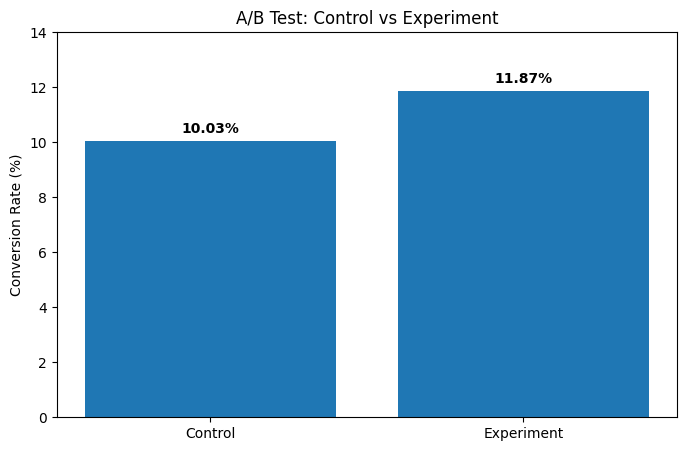

In [8]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["Control", "Experiment"],
    [control_rate, experiment_rate]
)

plt.ylabel("Conversion Rate (%)")
plt.title("A/B Test: Control vs Experiment")
plt.ylim(0, 14)

for i, value in enumerate([control_rate, experiment_rate]):
    plt.text(
        i,
        value + 0.3,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()